In [ ]:
!pip install serpapi google-search-results google-colab-selenium networkx


In [ ]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import time

from serpapi import GoogleSearch


import google_colab_selenium as gs
from selenium.webdriver.common.by import By



i used SerpAPI  to collect Amazon search results for headphones

### Collected data:
Title,
 Price,
 Rating,
 Reviews,
 Link.


In [ ]:
amazonProducts = []
api_key= "53c74d20c87e02f5ff4b309f2cdda0d03c845080971852748383898a2b253c83"
params = {
    "engine": "amazon",
    "amazon_domain": "amazon.com",
    "k": "headphones",
    "api_key": api_key
    }
try:
    search = GoogleSearch(params)
    results = search.get_dict()
    print(results)
    if "organic_results" in results:
        for item in results["organic_results"]:
            amazonProducts.append({
                "Title": item.get("title","N/A"),
                "Price": item.get("price","N/A"),
                "Rating": item.get("rating","N/A"),
                "Reviews": item.get("reviews","N/A"),
                "Link": item.get("link","N/A")
            })
    else:
        print("No SerpAPI results found.")

except Exception as e:
    print("api Error:",e)
df = pd.DataFrame(amazonProducts)
print("Products Found:", len(df))
df.head()

{'search_metadata': {'id': '69d96ab7bca7e5f93880065a', 'status': 'Success', 'json_endpoint': 'https://serpapi.com/searches/btEeo7D1xiHj_OL13Er6gg/69d96ab7bca7e5f93880065a.json', 'created_at': '2026-04-10 21:25:11 UTC', 'processed_at': '2026-04-10 21:25:11 UTC', 'amazon_url': 'https://www.amazon.com/s?k=headphones', 'raw_html_file': 'https://serpapi.com/searches/btEeo7D1xiHj_OL13Er6gg/69d96ab7bca7e5f93880065a.html', 'total_time_taken': 1.87}, 'search_parameters': {'engine': 'amazon', 'k': 'headphones', 'amazon_domain': 'amazon.com', 'device': 'desktop'}, 'search_information': {'total_results': 148051, 'query_displayed': 'headphones', 'store': 'gateway', 'page': 1}, 'product_ads': {'headline': 'Redefining the Sound of Sports', 'video_thumbnail': 'https://m.media-amazon.com/images/S/al-na-9d5791cf-3faf/da8dc713-7f5a-487a-b6eb-0432aa82cb6d.mp4/r/THUMBNAIL_360P_FRAME_3_CAPTURE_2.JPG', 'video_src': 'https://m.media-amazon.com/images/S/al-na-9d5791cf-3faf/da8dc713-7f5a-487a-b6eb-0432aa82cb6d.

,Title,Price,Rating,Reviews,Link
0,Soundcore by Anker Q20i Hybrid Active Noise Ca...,$39.99,4.6,59600,https://www.amazon.com/soundcore-Cancelling-He...
1,Soundcore by Anker Q20i Hybrid Active Noise Ca...,$39.98,4.6,59600,https://www.amazon.com/Soundcore-Cancelling-He...
2,Amazon Basics Bluetooth Headphones True Wirele...,$18.82,4.1,101,https://www.amazon.com/Amazon-Basics-Bluetooth...
3,"Apple AirPods Pro 3 Wireless Earbuds, Active N...",$224.00,4.5,7800,https://www.amazon.com/Apple-Cancellation-Tran...
4,JBL Tune 510BT - Bluetooth headphones with up ...,$29.95,4.5,90500,https://www.amazon.com/JBL-Tune-510BT-Ear-Head...


i scraped  with BeautifulSoup and it uses:
request,beautiffulsoup library
#collected data:
title,price,ratings,reviews,links

In [ ]:
bs_products = []
url = "https://www.amazon.com/s?k=headphones"
headers = {
    "User-Agent": "Mozilla/5.0 ",
    "Accept-Language": "en-US,en;q=0.9"
}
try:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    products = soup.find_all("div", {"data-component-type": "s-search-result"})
    for product in products[:10]:

        title_tag = product.find("span", class_="a-size-medium")
        if title_tag:
            title = title_tag.text.strip()
        else: "N/A"
        price_tag = product.find("span", class_="a-price-whole")
        if price_tag :
                price = price_tag.text.strip()
        else: "N/A"
        rating_tag = product.find("span", class_="a-icon-alt")
        if rating_tag:
            rating = rating_tag.text.strip().split()[0]
        else: "N/A"
        reviews_tag = product.find("span", class_="a-size-base s-underline-text")
        if reviews_tag:
            reviews = reviews_tag.text.strip().replace(",", "")
        else: "N/A"
        link_tag = product.find("a", class_="a-link-normal s-no-outline")
        if link_tag:
             link = "https://www.amazon.com" + link_tag.get("href")
        else: "N/A"
        bs_products.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Reviews": reviews,
            "Link": link,
        })
except  Exception as e :
    print("BeautifulSoup Error:",e)
print("BeautifulSoup Products Found:", len(bs_products))
pd.DataFrame(bs_products).head()


BeautifulSoup Products Found: 10


,Title,Price,Rating,Reviews,Link
0,p47m Wireless Bluetooth Headphone Cat RGB LED ...,951.,4.5,N/A,https://www.amazon.com/JBL-Tune-510BT-Ear-Head...
1,p47m Wireless Bluetooth Headphone Cat RGB LED ...,951.,4.6,N/A,https://www.amazon.com/Apple-Headphones-Cancel...
2,p47m Wireless Bluetooth Headphone Cat RGB LED ...,951.,4.4,N/A,https://www.amazon.com/Sony-WH-CH720N-Cancelin...
3,p47m Wireless Bluetooth Headphone Cat RGB LED ...,761.,4.8,N/A,https://www.amazon.com/HAOYUYAN-Bluetooth-Head...
4,p47m Wireless Bluetooth Headphone Cat RGB LED ...,634.,4.5,N/A,https://www.amazon.com/BERIBES-Bluetooth-Headp...


In [ ]:
selenium_products = []
try:
    driver=gs.Chrome()
    driver.get("https://www.amazon.eg/s?k=headphones")
    time.sleep(5)

    items = driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')

    for item in items[:10]:
        if item.find_elements(By.CSS_SELECTOR, "h2 span"):
            title = item.find_element(By.CSS_SELECTOR, "h2 span").text
        else:
            title="N/A"
        if item.find_elements(By.CSS_SELECTOR, "span.a-price-whole"):
            price = item.find_element(By.CSS_SELECTOR, "span.a-price-whole").text
        else:
            price="N/A"
        if item.find_elements(By.CSS_SELECTOR, "span.a-icon-alt"):
            text = item.find_element(By.CSS_SELECTOR, "span.a-icon-alt").text
            if text:
                 rating = text.split()[0]
            else :"N/A"
        else:
            rating = "N/A"
        if item.find_elements(By.CSS_SELECTOR, "span.a-size-base.s-underline-text"):
            reviews = item.find_element(By.CSS_SELECTOR, "span.a-size-base.s-underline-text").text
        else:
            reviews="N/A"
        if item.find_elements(By.CSS_SELECTOR, "h2 a"):
            link = item.find_element(By.CSS_SELECTOR, "h2 a").get_attribute("href")
        else:
            link="N/A"

        selenium_products.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Reviews": reviews,
            "Link": link
        })

    driver.quit()
except Exception as e:
    print("Selenium Error:", e)

print("Selenium Products Found:", len(selenium_products))

pd.DataFrame(selenium_products).head()



<IPython.core.display.Javascript object>

Selenium Products Found: 10


,Title,Price,Rating,Reviews,Link
0,"JBL Tune 520BT Wireless On-Ear Headphones, Pur...","1,749",4.5,N/A,N/A
1,"ANKER Soundcore Q11i Wireless Headphones, 40mm...","1,829",4.5,N/A,N/A
2,"P9 Wireless Bluetooth Headset, Support Pure St...",255,4.5,N/A,N/A
3,Sony mdrzx110apblack wired headphones - black ...,660,4.5,N/A,N/A
4,Sony WH-CH520 Wireless Bluetooth On-Ear with M...,"1,998",4.5,N/A,N/A


## Data Cleaning

i will clean:

-Price
-Rating
-Reviews

And convert them into numeric values for analysis.


In [ ]:
for column in ["Price", "Rating", "Reviews"]:
    df[column] = pd.to_numeric(df[column].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors="coerce")

df = df[df["Title"].notna()]

df.head()

,Title,Price,Rating,Reviews,Link
0,Soundcore by Anker Q20i Hybrid Active Noise Ca...,39.99,4.6,59600,https://www.amazon.com/soundcore-Cancelling-He...
1,Soundcore by Anker Q20i Hybrid Active Noise Ca...,39.98,4.6,59600,https://www.amazon.com/Soundcore-Cancelling-He...
2,Amazon Basics Bluetooth Headphones True Wirele...,18.82,4.1,101,https://www.amazon.com/Amazon-Basics-Bluetooth...
3,"Apple AirPods Pro 3 Wireless Earbuds, Active N...",224.00,4.5,7800,https://www.amazon.com/Apple-Cancellation-Tran...
4,JBL Tune 510BT - Bluetooth headphones with up ...,29.95,4.5,90500,https://www.amazon.com/JBL-Tune-510BT-Ear-Head...


## Product Relationship Network

Connect 2 products if:

Price difference < 70

This creates a simple graph showing products with similar prices.


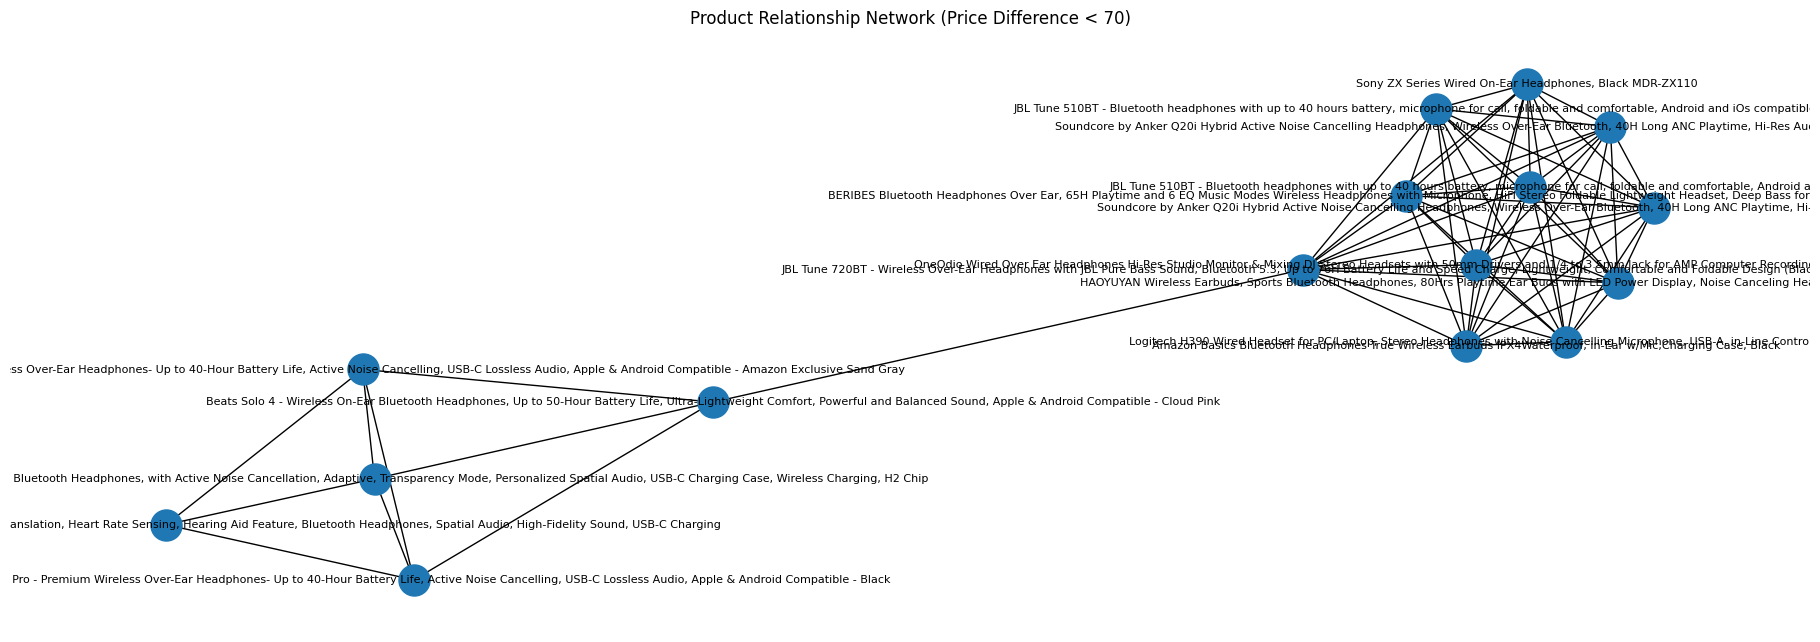

In [ ]:
network_df = df.dropna(subset=["Price"]).reset_index(drop=True)
G = nx.Graph()
for i in range(len(network_df)):
    G.add_node(network_df.loc[i, "Title"])
for i in range(len(network_df)):
    for j in range(i + 1, len(network_df)):
        price1 = network_df.loc[i, "Price"]
        price2 = network_df.loc[j, "Price"]
        if abs(price1 - price2) < 70:
            G.add_edge(network_df.loc[i, "Title"], network_df.loc[j, "Title"])
if len(G.nodes) > 0:
    plt.figure(figsize=(18, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=500, font_size=8)
    plt.title("Product Relationship Network (Price Difference < 70)")
    plt.show()
else:
    print("No network graph could be generated.")
